<a href="https://colab.research.google.com/github/nazuna-0/5CS037_FinalCourseWork/blob/Regression/Regression_Coursework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
from google.colab import files
print("'Video Game sales:")
uploaded = files.upload()

'Video Game sales:


Saving vgchartz-2024.csv to vgchartz-2024 (1).csv


Regression Task

### Part 1: EDA (Video Game Sales)
*   **What it does**: Cleans `vgchartz-2024.csv`, analyzes sales trends over time (**SDG 9 focus**), and visualizes sales by genre and console.

Total Rows in Dataset: 64016
Cleaned Rows: 56965

--- Summary Statistics ---
           year  total_sales
count  56965.00     18832.00
mean    2006.36         0.35
std        8.62         0.81
min     1971.00         0.00
25%     2001.00         0.03
50%     2008.00         0.12
75%     2012.00         0.35
max     2024.00        20.32


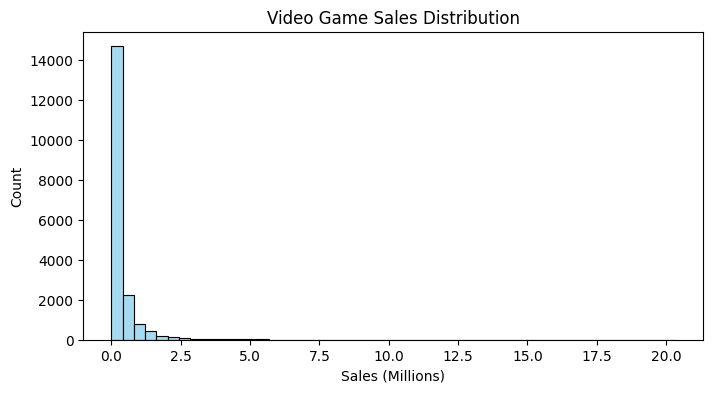

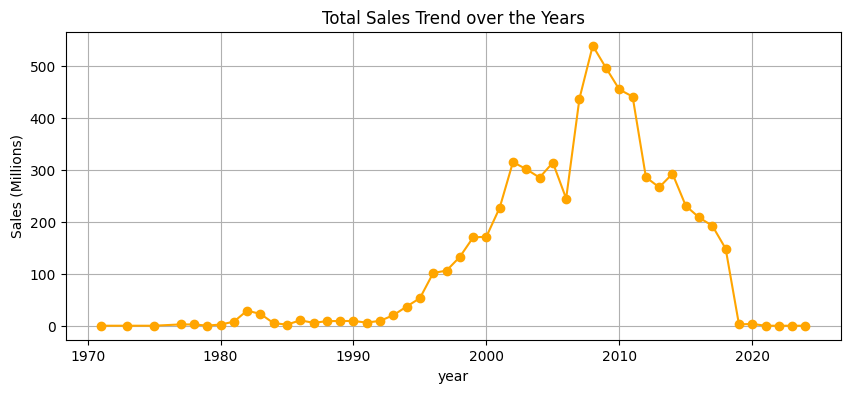

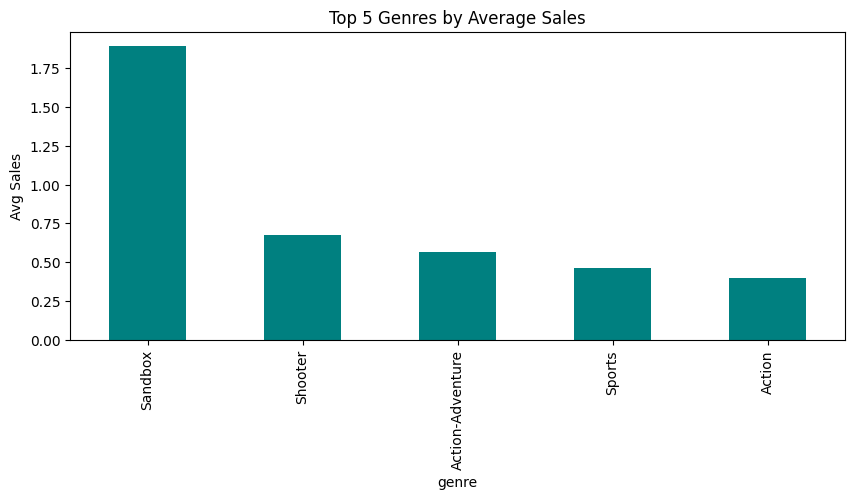


✓ Clean data saved as 'cleaned_videogame_sales.csv'

Missing values after cleaning:
title              0
console            0
genre              0
publisher          0
year               0
total_sales    38133
dtype: int64


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Load the Dataset
df = pd.read_csv('vgchartz-2024.csv')
print(f"Total Rows in Dataset: {df.shape[0]}")

# 2. Data Cleaning (The "Viva" steps)
# Standardize names to avoid "KeyErrors"
df.columns = df.columns.str.lower().str.strip()

# Help: The dataset has 'release_date' but we need 'year' for easier modeling.
if 'release_date' in df.columns:
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    df['year'] = df['release_date'].dt.year

# Rule: "Garbage In, Garbage Out".
# We remove rows with no Year or no Publisher to keep the data quality high.
df_clean = df.dropna(subset=['year', 'publisher'])
df_clean['year'] = df_clean['year'].astype(int)

# Select only the features we need to predict sales
cols = ['title', 'console', 'genre', 'publisher', 'year', 'total_sales']
df_clean = df_clean[[c for c in cols if c in df_clean.columns]]

print(f"Cleaned Rows: {df_clean.shape[0]}")
print("\n--- Summary Statistics ---")
print(df_clean.describe().round(2))

# 3. Simple Visualizations
# A. Distribution of Global Sales
plt.figure(figsize=(8, 4))
sns.histplot(df_clean['total_sales'], bins=50, color='skyblue')
plt.title('Video Game Sales Distribution')
plt.xlabel('Sales (Millions)')
plt.show()

# B. Market Trend over Time (SDG 9 Focus)
plt.figure(figsize=(10, 4))
df_clean.groupby('year')['total_sales'].sum().plot(kind='line', marker='o', color='orange')
plt.title('Total Sales Trend over the Years')
plt.ylabel('Sales (Millions)')
plt.grid(True)
plt.show()

# C. Top Genres
plt.figure(figsize=(10, 4))
df_clean.groupby('genre')['total_sales'].mean().sort_values(ascending=False).head(5).plot(kind='bar', color='teal')
plt.title('Top 5 Genres by Average Sales')
plt.ylabel('Avg Sales')
plt.show()

# 4. Save to CSV for next steps
df_clean.to_csv('cleaned_videogame_sales.csv', index=False)
print("\n✓ Clean data saved as 'cleaned_videogame_sales.csv'")

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())


### Part 2: Neural Network
*   **What it does**: Implements an `MLPRegressor` to predict continuous sales values. Includes a Loss Curve plot.

Training Neural Network... Please wait.

Train R-Squared: 0.1596
Test R-Squared:  0.0676
Test RMSE Error: 0.7948


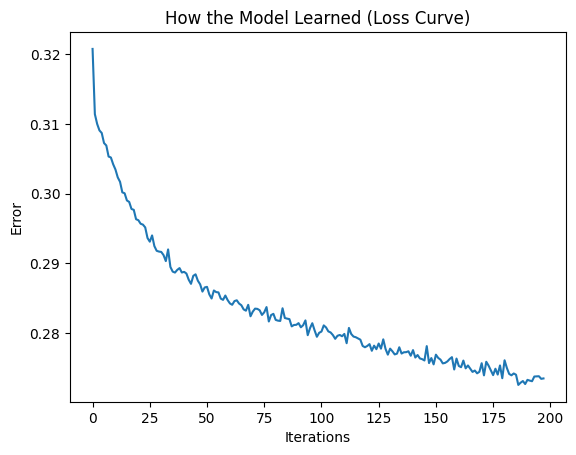

In [35]:
# =============================================================================
# STEP 2: REGRESSION NEURAL NETWORK (MLP)
# Student: Ashwini Tamang
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the cleaned data
df = pd.read_csv('cleaned_videogame_sales.csv')

# Safety check: Drop any NaNs that might have slipped through
df = df.dropna()

# 2. Encoding Text to Numbers
# Models only understand numbers, so we convert text columns.
for col in ['console', 'genre', 'publisher']:
    df[col] = LabelEncoder().fit_transform(df[col])

# Features (X) and Target (y)
X = df[['console', 'genre', 'publisher', 'year']]
y = df['total_sales']

# 3. Split the Data
# 80% to train the model, 20% to test it.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scaling (Viva Tip: Neural Networks work better when features stay between 0 and 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Build the Neural Network (MLP)
# Architecture: 2 hidden layers (64 and 32 neurons)
print("Training Neural Network... Please wait.")
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp.fit(X_train_scaled, y_train)

# 6. Evaluation
train_pred = mlp.predict(X_train_scaled)
test_pred = mlp.predict(X_test_scaled)

print(f"\nTrain R-Squared: {r2_score(y_train, train_pred):.4f}")
print(f"Test R-Squared:  {r2_score(y_test, test_pred):.4f}")
print(f"Test RMSE Error: {np.sqrt(mean_squared_error(y_test, test_pred)):.4f}")

# 7. Visualize Learning (Loss Curve)
plt.plot(mlp.loss_curve_)
plt.title('How the Model Learned (Loss Curve)')
plt.xlabel('Iterations')
plt.ylabel('Error')
plt.show()


### Part 3: Two Classical Models
*   **What it does**: Trains **Ridge Regression** and **Decision Tree**. Includes a "Residual Plot" to see if predictions are off.

Training Models...

Ridge Regression:
  RMSE Error: 0.8188
  R-Squared: 0.0103

Decision Tree:
  RMSE Error: 0.7632
  R-Squared: 0.1403

Best Model: Decision Tree


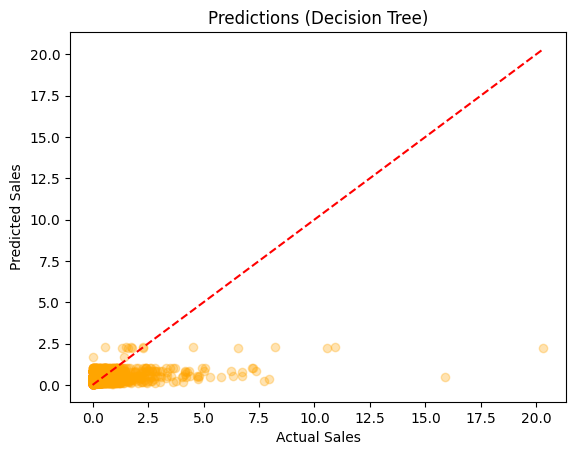

In [36]:
# =============================================================================
# STEP 3: CLASSICAL ML MODELS (Regression)
# Student: Ashwini Tamang
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load Data
df = pd.read_csv('cleaned_videogame_sales.csv')
df = df.dropna()

# 2. Encode Text to Numbers
for col in ['console', 'genre', 'publisher']:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df[['console', 'genre', 'publisher', 'year']]
y = df['total_sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create Models
models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)
}

print("Training Models...\n")
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    # Predict
    pred = model.predict(X_test)
    # Score
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    results[name] = r2 # Store R2 to find winner

    print(f"{name}:")
    print(f"  RMSE Error: {rmse:.4f}")
    print(f"  R-Squared: {r2:.4f}\n")

# 4. Identify the Best One
winner = max(results, key=results.get)
print(f"Best Model: {winner}")

# 5. Visual Check (Actual vs Predicted for Winner)
# Use the Decision Tree predictions as an example
dt_model = models["Decision Tree"]
dt_pred = dt_model.predict(X_test)

plt.scatter(y_test, dt_pred, alpha=0.3, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f'Predictions ({winner})')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.show()

In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
import warnings
warnings.filterwarnings('ignore')

# 1. Load & Prepare
df = pd.read_csv('cleaned_videogame_sales.csv')
df = df.dropna()
for col in ['console', 'genre', 'publisher']:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df[['console', 'genre', 'publisher', 'year']]
y = df['total_sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling (Important for Ridge)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 2. Hyperparameter Tuning (Finding the best settings)
print("Searching for the best settings (5-Fold Cross Validation)...\n")

# Model A: Ridge (Tuning 'alpha' - Regularization strength)
ridge_search = GridSearchCV(Ridge(), {'alpha': [1.0, 10.0, 100.0]}, scoring='neg_mean_squared_error')
ridge_search.fit(X_train_scaled, y_train)
print(f"Best Ridge Alpha: {ridge_search.best_params_}")

# Model B: Decision Tree (Tuning 'max_depth' - Tree height)
tree_search = GridSearchCV(DecisionTreeRegressor(random_state=42), {'max_depth': [5, 10, 15]}, scoring='neg_mean_squared_error')
tree_search.fit(X_train_scaled, y_train)
print(f"Best Tree Depth: {tree_search.best_params_}")

print("\n Hyperparameter tuning complete. Best settings found!")


Searching for the best settings (5-Fold Cross Validation)...

Best Ridge Alpha: {'alpha': 100.0}
Best Tree Depth: {'max_depth': 5}

 Hyperparameter tuning complete. Best settings found!


Finding top features...

Top 3 Features: ['console', 'genre', 'year']


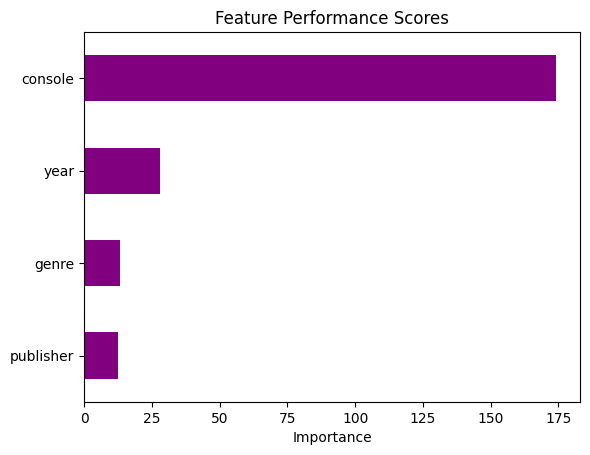

In [38]:
# =============================================================================
# STEP 5: FEATURE SELECTION (Regression)
# Student: Ashwini Tamang
# =============================================================================

import pandas as pd
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt

# 1. Load Data
df = pd.read_csv('cleaned_videogame_sales.csv')
df = df.dropna()
for col in ['console', 'genre', 'publisher']:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df[['console', 'genre', 'publisher', 'year']]
y = df['total_sales']

# 2. Select Features (SelectKBest)
# Justification for Viva:
# We use 'f_regression' to find which features have the strongest correlation with Sales.
# We pick top 3 to keep the model simple.
print("Finding top features...")
selector = SelectKBest(score_func=f_regression, k=3)
selector.fit(StandardScaler().fit_transform(X), y)

# Show which ones were picked
selected_features = X.columns[selector.get_support()]
print(f"\nTop 3 Features: {list(selected_features)}")

# 3. Simple Feature Importance Plot
scores = pd.Series(selector.scores_, index=X.columns)
scores.sort_values().plot(kind='barh', color='purple')
plt.title('Feature Performance Scores')
plt.xlabel('Importance')
plt.show()


In [40]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load data
df = pd.read_csv('cleaned_videogame_sales.csv')
df = df.dropna()
df.columns = df.columns.str.lower()

# 2. Encode categorical columns
for col in ['console', 'genre', 'publisher']:
    df[col] = LabelEncoder().fit_transform(df[col])

# 3. Features & target
X = df.drop(['title', 'total_sales'], axis=1)
y = df['total_sales']

# 4. Feature Selection (Top 3)
selector = SelectKBest(score_func=f_regression, k=3)
X_selected = selector.fit_transform(StandardScaler().fit_transform(X), y)

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

# 6. Build final models (using tuned / chosen settings)
models = [
    ("Ridge Regression", Ridge(alpha=100.0)),
    ("Decision Tree", DecisionTreeRegressor(max_depth=5, random_state=42))
]

results = []

# 7. Train, CV, Evaluate
for name, model in models:

    # Cross Validation (RMSE)
    cv_scores = -cross_val_score(
        model, X_train, y_train,
        cv=5,
        scoring='neg_root_mean_squared_error'
    )
    cv_rmse = cv_scores.mean()

    # Train on full training data
    model.fit(X_train, y_train)

    # Test prediction
    y_pred = model.predict(X_test)

    # Metrics
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_r2 = r2_score(y_test, y_pred)

    # Store
    results.append({
        "Model": name,
        "Features Used": "Selected (3)",
        "CV Score (RMSE)": round(cv_rmse, 4),
        "Test RMSE": round(test_rmse, 4),
        "Test R-squared": round(test_r2, 4)
    })

# 8. Print Final Table
print("\nTable 2: Comparison of Final Regression Models\n")
final_table = pd.DataFrame(results)
print(final_table.to_string(index=False))

# 9. Declare Winner
winner = final_table.loc[final_table['Test R-squared'].idxmax(), 'Model']
print(f"\n Final Winner: {winner}")


Table 2: Comparison of Final Regression Models

           Model Features Used  CV Score (RMSE)  Test RMSE  Test R-squared
Ridge Regression  Selected (3)           0.7998     0.8189          0.0102
   Decision Tree  Selected (3)           0.7792     0.7964          0.0636

 Final Winner: Decision Tree
